# Deliverable D4: Performance Analytics
This notebook calculates key performance metrics for mutual fund schemes including CAGR, Annualized Return, Annualized Volatility, Sharpe Ratio, Sortino Ratio, Beta, Alpha, Maximum Drawdown, Calmar Ratio, and Value at Risk (VaR).

The analysis uses historical NAV data and the NIFTY50 benchmark index.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'Inter'
plt.rcParams['font.family'] = 'sans-serif'

# Create output folder for CSVs
os.makedirs('../data/processed/metrics', exist_ok=True)


### Database Connection and Data Loading
We load historical NAV prices from `fact_nav` and join with `dim_fund` to get scheme names. We also load `NIFTY50` benchmark index values from `fact_benchmark_indices` to calculate Alpha and Beta.


In [2]:
# Connect to SQLite
conn = sqlite3.connect('../data/db/mutual_fund_analytics.db')

# Load NAV Data
query_nav = """
SELECT n.amfi_code, f.scheme_name, n.date, n.nav, f.category
FROM fact_nav n
JOIN dim_fund f ON n.amfi_code = f.amfi_code
WHERE n.date >= '2020-01-01'
ORDER BY n.amfi_code, n.date
"""
df_nav = pd.read_sql_query(query_nav, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Load Benchmark Data (NIFTY50)
query_bench = """
SELECT date, close_value as benchmark_close
FROM fact_benchmark_indices
WHERE index_name = 'NIFTY50' AND date >= '2020-01-01'
ORDER BY date
"""
df_bench = pd.read_sql_query(query_bench, conn)
df_bench['date'] = pd.to_datetime(df_bench['date'])
df_bench.set_index('date', inplace=True)
df_bench['benchmark_return'] = df_bench['benchmark_close'].pct_change()


In [3]:
# Preprocess NAV Data to compute daily returns
# Pivot to have dates as index and scheme names as columns
df_pivot = df_nav.pivot(index='date', columns='scheme_name', values='nav')

# Forward fill missing values
df_pivot = df_pivot.ffill().dropna()

# Compute daily returns
df_returns = df_pivot.pct_change().dropna()

# Merge with benchmark returns
df_combined = df_returns.join(df_bench['benchmark_return']).dropna()

# Select top 5 schemes by length of history for analysis
top_schemes = df_combined.drop(columns=['benchmark_return']).count().sort_values(ascending=False).index[:5]
print("Selected schemes for analysis:", top_schemes.tolist())


Selected schemes for analysis: ['ABSL Frontline Equity Fund - Regular - Growth', 'ABSL Liquid Fund - Regular - Growth', 'ABSL Small Cap Fund - Regular - Growth', 'Axis Bluechip Fund - Direct - Growth', 'Axis Bluechip Fund - Regular - Growth']


### 1. Annualized Return & CAGR
**Formula**: 
- CAGR = $(End Value / Start Value) ^ {(1 / Years)} - 1$
- Annualized Return = $((1 + R_1)(1 + R_2)...(1 + R_n)) ^ {(252 / n)} - 1$

**Why it matters**: It provides a standardized measure of growth per year, allowing for apple-to-apple comparison across different time periods.
**Interpretation**: Higher is better. Represents the geometric progression ratio that provides a constant rate of return over the time period.


In [4]:
TRADING_DAYS = 252
RISK_FREE_RATE = 0.05

def calc_annualized_return(returns):
    compound_growth = np.prod(1.0 + returns)
    return compound_growth ** (TRADING_DAYS / len(returns)) - 1.0

def calc_cagr(nav_series):
    start_val = nav_series.iloc[0]
    end_val = nav_series.iloc[-1]
    years = len(nav_series) / TRADING_DAYS
    return (end_val / start_val) ** (1 / years) - 1.0

results = {}
for scheme in top_schemes:
    results[scheme] = {}
    results[scheme]['Ann_Return'] = calc_annualized_return(df_combined[scheme])
    results[scheme]['CAGR'] = calc_cagr(df_pivot[scheme].loc[df_combined.index])


### 2. Annualized Volatility
**Formula**: $Volatility = Standard Deviation of Daily Returns 	imes \sqrt{252}$

**Why it matters**: It measures the dispersion of returns.
**Interpretation**: Higher volatility means higher risk and wider price swings.


In [5]:
def calc_ann_volatility(returns):
    return returns.std() * np.sqrt(TRADING_DAYS)

for scheme in top_schemes:
    results[scheme]['Ann_Volatility'] = calc_ann_volatility(df_combined[scheme])


### 3. Sharpe & Sortino Ratios
**Formula**:
- Sharpe Ratio = $(Annualized Return - Risk Free Rate) / Annualized Volatility$
- Sortino Ratio = $(Annualized Return - Risk Free Rate) / Downside Deviation$

**Why it matters**: Measures risk-adjusted returns. Sortino only penalizes downside volatility.
**Interpretation**: $> 1.0$ is generally considered good. Higher values indicate better risk-adjusted performance.


In [6]:
def calc_sharpe(ann_return, ann_vol):
    return (ann_return - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0

def calc_sortino(returns, ann_return):
    downside_returns = returns[returns < 0]
    downside_dev = downside_returns.std() * np.sqrt(TRADING_DAYS)
    return (ann_return - RISK_FREE_RATE) / downside_dev if downside_dev > 0 else 0

for scheme in top_schemes:
    ret = results[scheme]['Ann_Return']
    vol = results[scheme]['Ann_Volatility']
    results[scheme]['Sharpe_Ratio'] = calc_sharpe(ret, vol)
    results[scheme]['Sortino_Ratio'] = calc_sortino(df_combined[scheme], ret)


### 4. Beta & Alpha
**Formula**:
- Beta = $Covariance(Fund Returns, Market Returns) / Variance(Market Returns)$
- Alpha = $Annualized Fund Return - [Risk Free Rate + Beta 	imes (Annualized Market Return - Risk Free Rate)]$

**Why it matters**: Beta measures systemic market risk. Alpha measures the value the manager added beyond the market exposure.
**Interpretation**: Alpha $> 0$ implies the manager generated excess returns. Beta $> 1$ means more volatile than the market.


In [7]:
ann_market_return = calc_annualized_return(df_combined['benchmark_return'])

def calc_beta_alpha(fund_ret, market_ret, ann_fund, ann_market):
    cov_matrix = np.cov(fund_ret, market_ret)
    beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] > 0 else 1
    
    expected_return = RISK_FREE_RATE + beta * (ann_market - RISK_FREE_RATE)
    alpha = ann_fund - expected_return
    return beta, alpha

for scheme in top_schemes:
    b, a = calc_beta_alpha(df_combined[scheme], df_combined['benchmark_return'], results[scheme]['Ann_Return'], ann_market_return)
    results[scheme]['Beta'] = b
    results[scheme]['Alpha'] = a


### 5. Maximum Drawdown & Calmar Ratio
**Formula**:
- Max Drawdown = $Minimum of (Peak to Trough drop in portfolio value)$
- Calmar Ratio = $Annualized Return / Absolute(Max Drawdown)$

**Why it matters**: Drawdown measures the largest historical loss. Calmar measures return relative to this maximum downside risk.
**Interpretation**: Lower drawdown is safer. Higher Calmar Ratio ($> 1$) is excellent.


In [8]:
def calc_max_drawdown(nav_series):
    rolling_max = nav_series.cummax()
    drawdown = (nav_series - rolling_max) / rolling_max
    return drawdown.min()

for scheme in top_schemes:
    nav_series = df_pivot[scheme].loc[df_combined.index]
    mdd = calc_max_drawdown(nav_series)
    results[scheme]['Max_Drawdown'] = mdd
    results[scheme]['Calmar_Ratio'] = results[scheme]['Ann_Return'] / abs(mdd) if mdd != 0 else 0


### 6. Value at Risk (VaR)
**Formula**:
- Historical VaR (95%) = $5th Percentile of Historical Daily Returns$
- Parametric VaR (95%) = $Mean - 1.645 	imes Standard Deviation$

**Why it matters**: Estimates the maximum potential loss over a specific timeframe with a given confidence interval.
**Interpretation**: A 95% 1-Day VaR of -2% means we are 95% confident the fund will not lose more than 2% in a single day.


In [9]:
def calc_var(returns, confidence_level=0.05):
    hist_var = np.percentile(returns, confidence_level * 100)
    
    mean_ret = returns.mean()
    std_ret = returns.std()
    z_score = norm.ppf(confidence_level)
    param_var = mean_ret + z_score * std_ret
    
    return hist_var, param_var

for scheme in top_schemes:
    h_var, p_var = calc_var(df_combined[scheme])
    results[scheme]['Historical_VaR_95'] = h_var
    results[scheme]['Parametric_VaR_95'] = p_var


### Summary & CSV Export
Saving all calculated metrics to `data/processed/metrics/performance_metrics.csv`.


In [10]:
df_results = pd.DataFrame(results).T
df_results = df_results.round(4)
display(df_results)

# Export to CSV
csv_path = '../data/processed/metrics/performance_metrics.csv'
df_results.to_csv(csv_path)
print(f"Metrics successfully saved to {csv_path}")


,Ann_Return,CAGR,Ann_Volatility,Sharpe_Ratio,Sortino_Ratio,Beta,Alpha,Max_Drawdown,Calmar_Ratio,Historical_VaR_95,Parametric_VaR_95
ABSL Frontline Equity Fund - Regular - Growth,0.2263,0.2260,0.1457,1.2099,2.1197,0.0338,0.1775,-0.1129,2.0038,-0.0133,-0.0142
ABSL Liquid Fund - Regular - Growth,0.0627,0.0628,0.0051,2.5154,5.1847,0.0013,0.0128,-0.0016,38.6681,-0.0003,-0.0003
ABSL Small Cap Fund - Regular - Growth,0.0765,0.0791,0.2580,0.1027,0.1747,-0.0599,0.0243,-0.3545,0.2158,-0.0260,-0.0263
Axis Bluechip Fund - Direct - Growth,0.0761,0.0761,0.1398,0.1867,0.3184,-0.0084,0.0258,-0.2175,0.3499,-0.0142,-0.0142
Axis Bluechip Fund - Regular - Growth,0.0614,0.0629,0.1395,0.0816,0.1393,-0.0196,0.0106,-0.1440,0.4262,-0.0137,-0.0142


Metrics successfully saved to ../data/processed/metrics/performance_metrics.csv


### Visualizations
Plotting Risk vs Return (Annualized Volatility vs Annualized Return) and Max Drawdown comparisons.


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


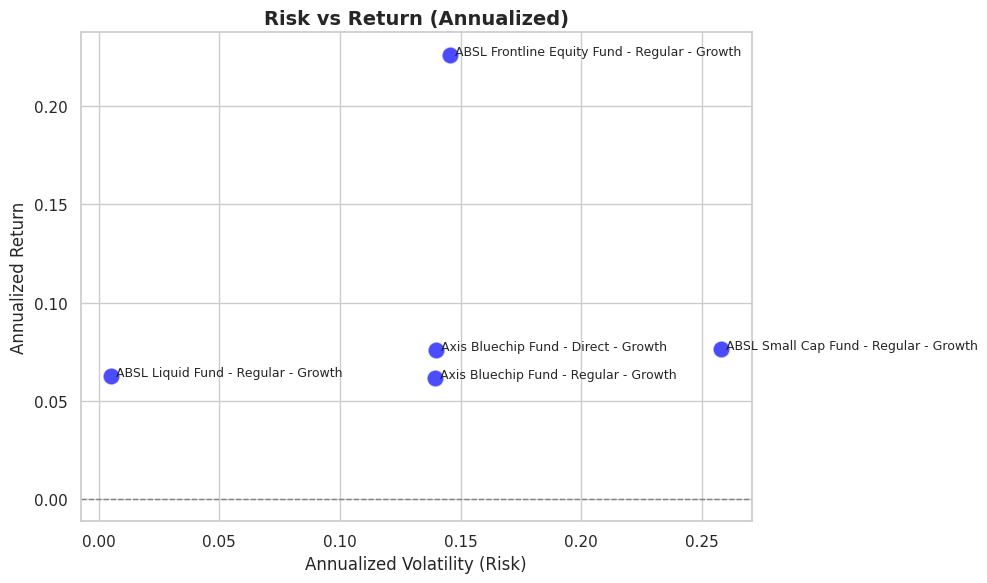

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


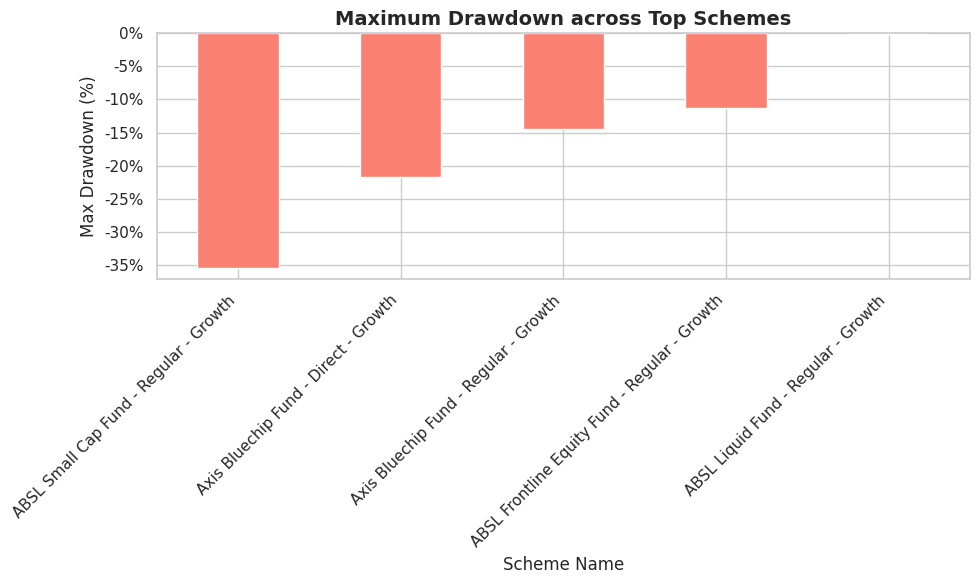

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


findfont: Generic family 'sans-serif' not found because none of the following families were found: Inter


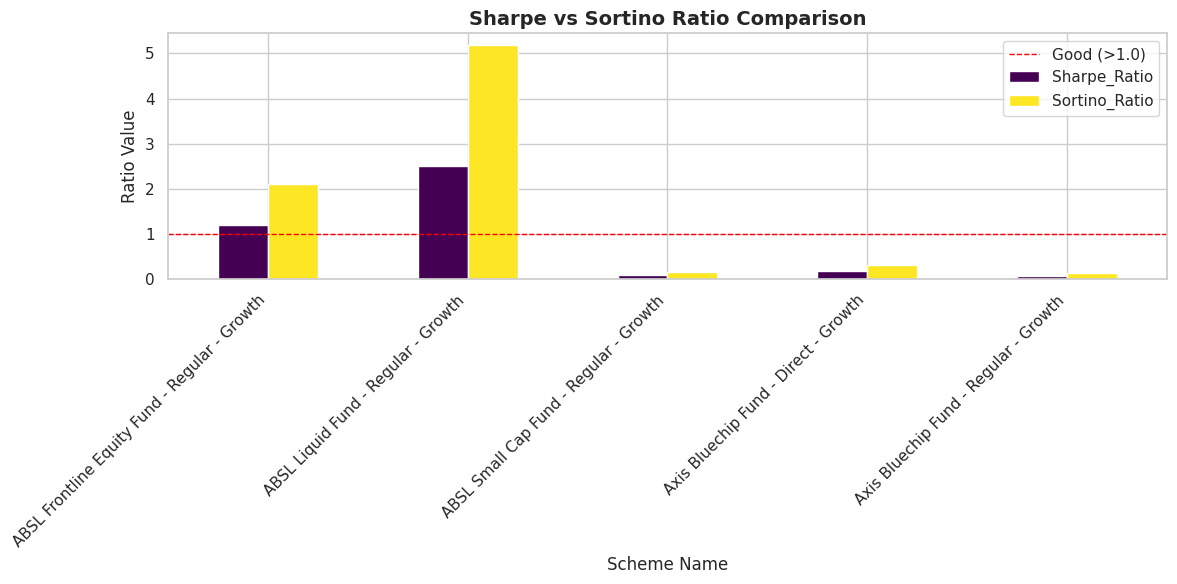

In [11]:
# 1. Risk vs Return Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ann_Volatility', y='Ann_Return', data=df_results, s=150, color='blue', alpha=0.7)
for idx, row in df_results.iterrows():
    plt.text(row['Ann_Volatility'] + 0.002, row['Ann_Return'], idx, fontsize=9)
plt.title('Risk vs Return (Annualized)', fontsize=14, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

# 2. Maximum Drawdown Bar Chart
plt.figure(figsize=(10, 6))
df_results['Max_Drawdown'].sort_values().plot(kind='bar', color='salmon')
plt.title('Maximum Drawdown across Top Schemes', fontsize=14, fontweight='bold')
plt.xlabel('Scheme Name')
plt.ylabel('Max Drawdown (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Sharpe vs Sortino Ratios
df_results[['Sharpe_Ratio', 'Sortino_Ratio']].plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Sharpe vs Sortino Ratio Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Scheme Name')
plt.ylabel('Ratio Value')
plt.xticks(rotation=45, ha='right')
plt.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Good (>1.0)')
plt.legend()
plt.tight_layout()
plt.show()

# Close db
conn.close()
